# 6. Candidate vs Party Performance
Scatter plot คะแนนผู้สมัคร (เขต) vs คะแนนพรรค (บช) รายหน่วย

- **เหนือเส้น diagonal** = ผู้สมัครแข็งแกร่งกว่าพรรค
- **ใต้เส้น diagonal** = พรรคแข็งแกร่งกว่าผู้สมัคร

In [1]:
import sys
!{sys.executable} -m pip install folium scikit-learn matplotlib seaborn -q

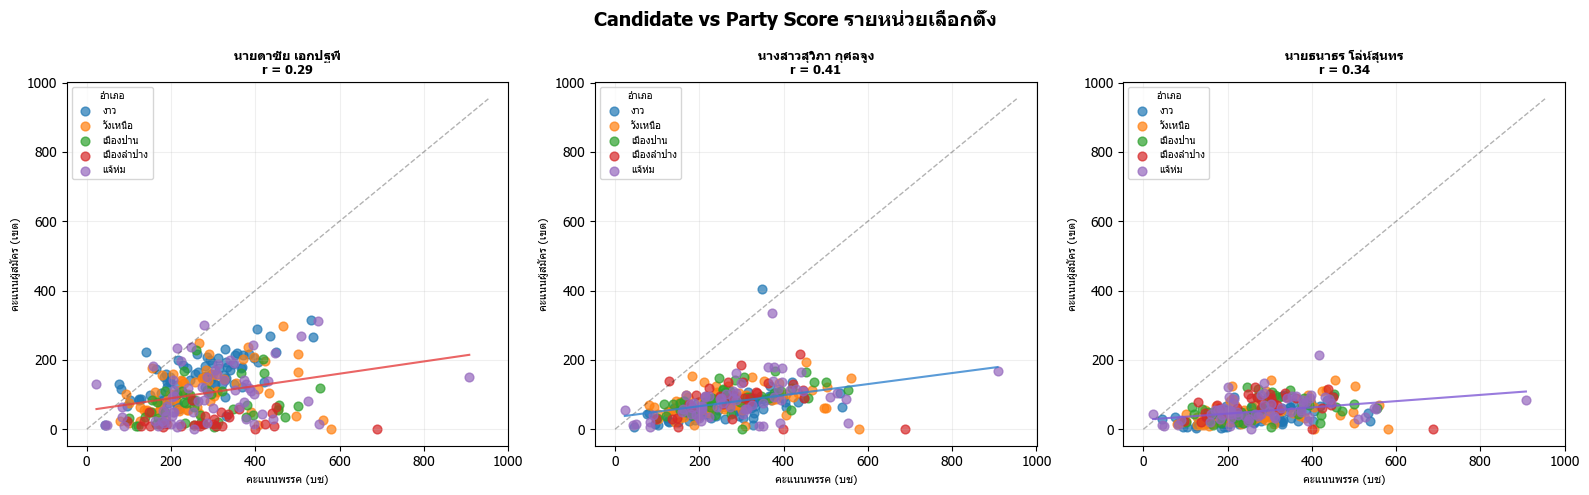


หน่วยที่ นายดาซัย ทำได้ดีกว่าพรรค (cand > party):
district sub-district  unit_number  cand_score  party_score  diff
  แจ้ห่ม     วิเชตนคร            8         129           23   106
     งาว     บ้านโป่ง            3         224          140    84
     งาว      บ้านหวด            6         131           76    55
     งาว     บ้านโป่ง           11         116           81    35
  แจ้ห่ม     เมืองมาย            2         182          158    24
  แจ้ห่ม       บ้านสา            9         302          279    23
วังเหนือ      วังซ้าย            2         176          154    22
  แจ้ห่ม     วิเชตนคร            3         233          214    19
วังเหนือ     ทุ่งฮั้ว           10         102           92    10
     งาว        ปงเตา            9         173          164     9


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Tahoma','DejaVu Sans']
from pathlib import Path

CLEAN = Path('../cleaned/')
results = pd.read_csv(CLEAN / 'master_results_cleaned.csv')

JOIN = ['district', 'sub-district', 'unit_number']
r = results[results['unit_number'] != -1]
bch = r[r['type'] == 'บช']
ket = r[r['type'] == 'เขต']

# คะแนนรวม บช รายหน่วย
bch_unit = bch.groupby(JOIN)['score'].sum().reset_index().rename(columns={'score':'party_score'})

# Top 3 ผู้สมัครที่น่าสนใจ
top3 = ['นายดาซัย เอกปฐพี', 'นางสาวสุวิภา กุศลจูง', 'นายธนาธร โล่ห์สุนทร']
cand_colors = {'นายดาซัย เอกปฐพี': '#E53E3E',
               'นางสาวสุวิภา กุศลจูง': '#3182CE',
               'นายธนาธร โล่ห์สุนทร': '#805AD5'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Candidate vs Party Score รายหน่วยเลือกตั้ง', fontsize=14, fontweight='bold')

for ax, cand in zip(axes, top3):
    cdf = ket[ket['name'] == cand].groupby(JOIN)['score'].sum().reset_index().rename(columns={'score':'cand_score'})
    # district อยู่ใน JOIN แล้ว ไม่ต้อง merge เพิ่ม
    merged = cdf.merge(bch_unit, on=JOIN)

    color = cand_colors[cand]
    for dist, grp in merged.groupby('district'):
        ax.scatter(grp['party_score'], grp['cand_score'],
                   label=dist, alpha=0.7, s=40)

    # diagonal line
    maxv = max(merged['party_score'].max(), merged['cand_score'].max()) * 1.05
    ax.plot([0, maxv], [0, maxv], 'k--', alpha=0.3, linewidth=1)

    # regression line
    x, y = merged['party_score'], merged['cand_score']
    m, b = np.polyfit(x, y, 1)
    ax.plot(np.sort(x), m * np.sort(x) + b, color=color, linewidth=1.5, alpha=0.8)

    corr = merged['party_score'].corr(merged['cand_score'])
    ax.set_title(f'{cand}\nr = {corr:.2f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('คะแนนพรรค (บช)', fontsize=8)
    ax.set_ylabel('คะแนนผู้สมัคร (เขต)', fontsize=8)
    ax.legend(fontsize=7, title='อำเภอ', title_fontsize=7)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# สรุป: หน่วยที่ผู้สมัครทำได้ดีกว่าพรรค
print('\nหน่วยที่ นายดาซัย ทำได้ดีกว่าพรรค (cand > party):')
cdf = ket[ket['name'] == 'นายดาซัย เอกปฐพี'].groupby(JOIN)['score'].sum().reset_index().rename(columns={'score':'cand_score'})
merged = cdf.merge(bch_unit, on=JOIN)
merged['diff'] = merged['cand_score'] - merged['party_score']
print(merged.sort_values('diff', ascending=False).head(10)[JOIN + ['cand_score','party_score','diff']].to_string(index=False))

